In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [4]:
# Load Boston Housing dataset from keras datasets
from tensorflow.keras.datasets import boston_housing

# Load the data
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")


57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


In [5]:
# Standardizing features (important for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# Building the model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Single neuron output (because it's regression)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


d:\collegePrograms\sem8\prac\myenv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - loss: 556.4953 - mae: 21.8130 - val_loss: 593.5976 - val_mae: 22.5166
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 527.3500 - mae: 21.0018 - val_loss: 543.0208 - val_mae: 21.3702
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 431.7946 - mae: 19.0319 - val_loss: 479.1857 - val_mae: 19.8590
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 398.6157 - mae: 17.8050 - val_loss: 397.4143 - val_mae: 17.8249
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 347.5634 - mae: 16.4406 - val_loss: 298.2558 - val_mae: 14.9923
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 226.3334 - mae: 12.8726 - val_loss: 200.8305 - val_mae: 11.5684
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 139.8096 - mae: 9.3301 - val_loss: 126.4552 - val_mae: 8.4471
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 86.7850 - mae: 6.9083 - val_loss: 85.2238 - val_mae: 6.8905
Epoch 9/100


In [8]:
# Evaluate on Test Set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=2)

print(f"Test Loss (MSE): {test_loss:.2f}")
print(f"Test MAE: {test_mae:.2f}")


4/4 - 0s - 27ms/step - loss: 28.3186 - mae: 3.2342
Test Loss (MSE): 28.32
Test MAE: 3.23


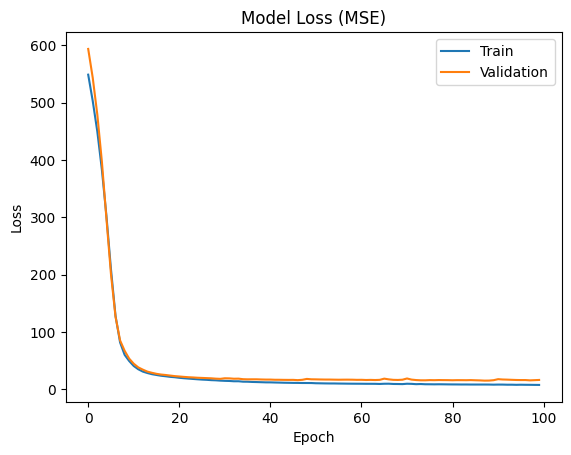

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


In [11]:
# Make predictions
predictions = model.predict(X_test_scaled)

# Display first 5 predictions vs actual prices
for i in range(5):
    print(f"Predicted Price: {predictions[i][0]:.2f}, Actual Price: {y_test[i]}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Price: 9.02, Actual Price: 7.2
Predicted Price: 17.91, Actual Price: 18.8
Predicted Price: 21.64, Actual Price: 19.0
Predicted Price: 32.40, Actual Price: 27.0
Predicted Price: 25.27, Actual Price: 22.2


1. What is the purpose of this code?
Answer:
The code builds and trains a deep neural network to predict Boston housing prices using linear regression.

2. Which dataset are you using? How do you load it?
Answer:
I am using the Boston Housing dataset.
It is loaded from tensorflow.keras.datasets.boston_housing.

3. Why are you using StandardScaler?
Answer:
I use StandardScaler to standardize the features so that they have zero mean and unit variance.
This helps neural networks converge faster and perform better.

4. What does the model architecture look like?
Answer:
The model is sequential with:

Two hidden layers, each having 64 neurons and ReLU activation,

One output layer with 1 neuron (since it's a regression task).

5. Which optimizer and loss function did you use, and why?
Answer:
I used the Adam optimizer because it is efficient and adapts learning rates during training.
The loss function is Mean Squared Error (MSE) because it is standard for regression problems.

6. What metrics are you monitoring during training?
Answer:
I am monitoring Mean Absolute Error (MAE) as an additional evaluation metric.

7. What does validation_split=0.2 mean in model fitting?
Answer:
It means 20% of the training data is used for validation during training, to monitor model performance and detect overfitting.

8. What does the verbose=1 parameter do in .fit()?
Answer:
It makes the training process output progress bars and metrics per epoch.

9. How do you evaluate the model after training?
Answer:
I evaluate it on the test dataset using .evaluate(), which returns the test loss (MSE) and MAE.

10. Why are you plotting loss curves?
Answer:
To visualize the training and validation loss over epochs,
which helps in detecting overfitting or underfitting.

11. How do you make predictions?
Answer:
Using the trained model's .predict() function on the scaled test features.

12. Why is the output layer a single neuron without activation?
Answer:
Because it's a regression task and we need a continuous real-valued output,
not probabilities or categories.

13. What is the difference between MSE and MAE?
Answer:

MSE penalizes large errors more heavily (squares the errors).

MAE treats all errors linearly.
MSE is more sensitive to outliers.

14. Why do we need two hidden layers? Can't one layer work?
Answer:
One layer can work, but adding a second hidden layer allows the model to capture more complex patterns in the data.

15. How many features does each input sample have?
Answer:
Each sample has 13 features.